# Overview:
- Brain is a bunch of interconnected neurons whose interactions give rise to cognition. It therefore serves neuroscientist well to use machine learning techniques equipped to handle networked or graph-like data.
- GNNs can be used to extract information from anatomical and functional connectomes, often obtain via MRI.

## What are GNNs
- The issue with standard neurl networks
- Neural network have proved powerful in domains such as image recognition and language generation. However, current state-of-art models have a fundamental limitation: they learn from data that is structurally regular. An image can be though of as a 2D, while a setence is particular language can be represented as a 1D array of words.
- Standard models also normally reply on a notion of order in the input data to make meaningful predictions. The output we get from passing `do re mi` into a language model differs from the output we get from passing in `mi re do`.
- So. How might we assign order to regions of the brain?
- Given these points, we need to find an architecture that
  1. Can learn over inputs of arbitrary structure
  2. Make the same predictions regardless of ordering

## GNN
- GNNs statisfy these requirements!
- One fundamental modeling assumption GNNs makes is `Node that share edges tend to have similar properties/labels`.
- So if we have a graph consisting of nodes, each node having feature vector, we want each node v to obtain information about the features of its neighbors (i.e, nodes that share edges with v). Node v's features/embedding can then be refined by aggregating information it gets from its neighbors.
- Nodes that aggregate information from their neighbors leverage graph structure in addition to features. Since nodes only receive information from neighbors, information only flows across edegs of the graph.
- 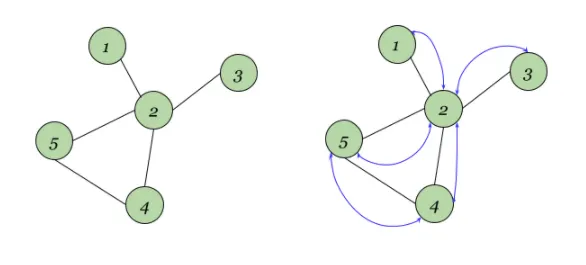

- Each GNN forward pass performs this neighborhood aggrgeation process
  1. For each node v, we look at all of its neighbors N(v) (nodes that share an edge with v)
  2. Each node u in N(v) prepares a message m(u): this is the information u will pass on about itself to v.
  3. Node v collects the messages from its neighbors, and aggregates them into one summary vector: AGGREGATE({M(u), u in N(v)}).
  4. Node v updates its embedding by combining its initial embeddding with the aggregated result.
- 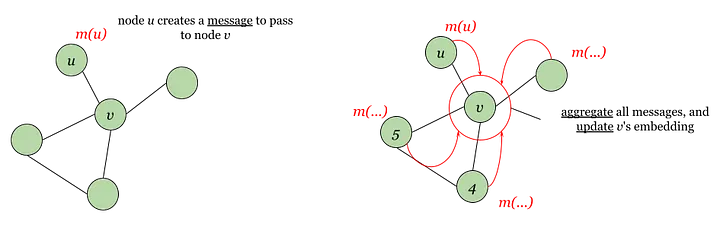

- An example message function might just be a node passing forward its exisiting representation: m(u) = u. An example aggregation function might be the sum of all m(u)'s. By stacking some number of these layers, we can refine node embeddings which can be used to make predictions.
- Let's check that the archtiecture we just outlined statisfied the 2 requirements we mentioned.
  1. The model can ingest inputs of arbitrary structure.
  2. The model makes the same predictions regardless of the ordering.
- Our model takes graphs as input after all. (2) because in message passing and aggrgeation we do to tink about node ordering: we simply collect an orderless set of messages and perform aggregation on this orderless set.

# GNN in neuroscience: Graph Convolution networks for fRMI analysis.
- 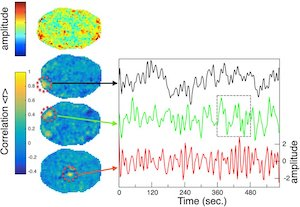

- Functional connectomes, which encode the many temporall statistical relationships amongst brain regions.
- Functional magnetic resonance imaging (fMRI) is one useful technique that an help us map our brain activity so that we can discover these statistical relationships.
- From fMRI data we can derive functional connectivity matrices or graphs where rows/columns (nodes) represent brain region of interest (ROIs) and entries (edges) represent strenght and direction of functional connection (e.g. correlation coefficients).
- GNNs learn rich features from connectivity matrices because unlinke CNNs they leverage the full connectome (rather than Euclidean neighborhood of the given ROI). In GNNs convolution ocurrs over adjacency nodes rather than adjacency pixels, allowing for the arbitrary structrural composition that temporaral patterns in brain activity tend to consitute (i.e ROIs that adjoin spatially do not necessarily co-active). Each ROI defines its own computation graph defined by its edges, or the ROIs with which it shares functional connection.

# 0. INSTALL DEPENDENCIES

In [ ]:
# Clone the repository here
!git clone https://github.com/ssmaheswar2001/BrainGraphGNN.git

Cloning into 'BrainGraphGNN'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.


In [3]:
!pip install -r /content/BrainGraphGNN/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.6 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=664632 sha256=de0737414b1c7f3bb0b03ac79177cc102b9c42b2040c18fd4d70d4bed7082ef9
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp312-cp312

## 1. IMPORT ALL LIBRARIES

In [78]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from scipy import stats

# To extract the datasets from nilearn
from nilearn import datasets
from nilearn import plotting
# Extract data from Niimgike objects using maps of potentially overlapping brain regions
# NifitMapsMasker is useful when data from overlapping volumes should be extracted
from nilearn.maskers import NiftiMapsMasker
# Computes different kinds of functional connectivity
from nilearn.connectome import ConnectivityMeasure

import torch
from torch import nn
from torch.nn import functional as F
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv
from torch_geometric.nn import global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.nn import BatchNorm, LayerNorm
from torch_geometric.loader import DataLoader
from torch_geometric.data import InMemoryDataset, Data
from torch.utils.data import WeightedRandomSampler
# used to conver a graph object from the standard python networkx library.
# This conversion allows users to easily define or generate graphs using the
# extensive features of the networkx libary and then leverage the functionalities of Py/G for training GNN
from torch_geometric.utils import from_networkx
from torch_geometric.data.data import DataEdgeAttr

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

import networkx as nx
# Used to create a graph from a 2D numpy array, which it interprets as an adjacency matrix
from networkx import from_numpy_array

print("✓ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

✓ All libraries imported successfully!
PyTorch version: 2.9.0+cpu
CUDA available: False
Using device: cpu


# 2. LOAD AND PREPARE DATA
- OpenNeuro is a resoruce with lots of resting-state and task-based fMRI datasets.
- If we want to run our own experiements, keep an eye out fr `BIDS valid` data - this means that data is formatted accordingly to a common neuroimaging specification that will make processing easier.
- Tasks a GNN could learn include:
  - Predicting whether or not a subject has depression
  - Predicting a subject's IQ
  - Predicting what genre of music a subject is listening to
- In this, we'll look at MRI data of 3-12 year old children and adults during viewing of a short animated film. The task will be predict the age of a participant given fMRI scans taken while subject watched PiXas's `Party Cloudy`. Specifically, we want to know if child is watching or an adult is watching (the problem is binary).
- This 155 subject dataset has already has a popular processing pipeline run on its know as fMRIPrep. If we're working with our own data, make sure we run fMRIPrep or some other preprocessing pipeline 1st: the images need robust deonising, normalization, and smoothing to produce reliable results. In fMRI scans factors such as head movement can generate spurios signal fluctuations can greatly affect quality of data.

## fMRIPrep: A Robust preprocessing pipeline for fMRI data.
  - fMRIPrep is a NiPreps (NeuroImaging PREProcessing toolS) application for the processing of task-based and resting-state function MRI (fMRI).
  - It performs basic processing steps (coregistration, normalization, unwarping, noise component extraction, segmentation, sull-stripping, etc) providing output that can easily submitted to a varitey of group level analyses, including task-based or resting-state fMRI, graph theory measurements, and surface or volume base statisticas.
  - The fMRIPrep pipeline uses a combination of tools from well-known software packages including FSL, ANTs, FreeSurfer and AFNI.
  - To get started with machine learning on neuroimaging data, we use Nilearn, a Python package that offers great neuroscience-specific utility functions and compatibility with common formats in the field. Here we use Nilearn to retrive our dataset, as well as an atlas that parcellates the brain into ROIs.

In [5]:
# Create a directories that our dataset will be saved in
from IPython.core.logger import time

dataset_path = 'dataset'
corr_matrices_dir = f'{dataset_path}/corr_matrices'
pcorr_matrices_dir = f'{dataset_path}/pcorr_matrices'
tan_matrices_dir = f'{dataset_path}/tan_matrices'
avg_pcorr_file = f'{dataset_path}/avg_pcorr.csv'
time_series_dir = f'{dataset_path}/time_series'
labels_file = f'{dataset_path}/labels.csv'

os.makedirs(corr_matrices_dir)
os.makedirs(pcorr_matrices_dir)
os.makedirs(tan_matrices_dir)
os.makedirs(time_series_dir)

- Fetch an atlas that paracellates the brain into regions of interest (ROIs), and fetch the raw fMRI data from OpenNeuro

In [6]:
atlas = datasets.fetch_atlas_msdl()
atlas

[fetch_atlas_msdl] Added README.md to /root/nilearn_data

[fetch_atlas_msdl] Dataset created in /root/nilearn_data/msdl_atlas

[fetch_atlas_msdl] Downloading data from https://team.inria.fr/parietal/files/2015/01/MSDL_rois.zip ...

[fetch_atlas_msdl]  ...done. (1 seconds, 0 min)

[fetch_atlas_msdl] Extracting data from 
/root/nilearn_data/msdl_atlas/dedd5c670ed1fd457a722109d3c7f958/MSDL_rois.zip...

[fetch_atlas_msdl] .. done.

{'maps': '/root/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii',
 'labels': ['L Aud',
  'R Aud',
  'Striate',
  'L DMN',
  'Med DMN',
  'Front DMN',
  'R DMN',
  'Occ post',
  'Motor',
  'R DLPFC',
  'R Front pol',
  'R Par',
  'R Post Temp',
  'Basal',
  'L Par',
  'L DLPFC',
  'L Front pol',
  'L IPS',
  'R IPS',
  'L LOC',
  'Vis',
  'R LOC',
  'D ACC',
  'V ACC',
  'R A Ins',
  'L STS',
  'R STS',
  'L TPJ',
  'Broca',
  'Sup Front S',
  'R TPJ',
  'R Pars Op',
  'Cereb',
  'Dors PCC',
  'L Ins',
  'Cing',
  'R Ins',
  'L Ant IPS',
  'R Ant IPS'],
 'description': ".. _msdl_atlas:\n\nMSDL atlas\n==========\n\nAccess\n------\nSee :func:`nilearn.datasets.fetch_atlas_msdl`.\n\nNotes\n-----\nMulti-subject Dictionary learning atlas.\n\nResult maps of sparse :term:`Dictionary learning` based on :term:`resting-state` data.\n\nThis can be understand as a variant of :term:`ICA` based on the assumption\nof sparsity rather than independence.\n\nIt can be downloaded at :footcite:t:`atlas_msdl`

In [7]:
atlas_filename = atlas.maps
atlas_filename

'/root/nilearn_data/msdl_atlas/MSDL_rois/msdl_rois.nii'

In [8]:
atlas_labels = atlas.labels
atlas_labels

['L Aud',
 'R Aud',
 'Striate',
 'L DMN',
 'Med DMN',
 'Front DMN',
 'R DMN',
 'Occ post',
 'Motor',
 'R DLPFC',
 'R Front pol',
 'R Par',
 'R Post Temp',
 'Basal',
 'L Par',
 'L DLPFC',
 'L Front pol',
 'L IPS',
 'R IPS',
 'L LOC',
 'Vis',
 'R LOC',
 'D ACC',
 'V ACC',
 'R A Ins',
 'L STS',
 'R STS',
 'L TPJ',
 'Broca',
 'Sup Front S',
 'R TPJ',
 'R Pars Op',
 'Cereb',
 'Dors PCC',
 'L Ins',
 'Cing',
 'R Ins',
 'L Ant IPS',
 'R Ant IPS']

In [9]:
data = datasets.fetch_development_fmri()

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri

[fetch_development_fmri] Added README.md to /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset created in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...

[fetch_development_fmri]  ...done. (1 seconds, 0 min)

...

[fetch_development_fmri]  ...done. (1 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5cb4700cf2be3c0017056f70/ ...

[fetch_development_fmri]  ...done. (1 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5cb46e4fa3bc970019f0713b/ ...

[fetch_development_fmri]  ...done. (1 seconds, 0 min)

In [10]:
data

{'func': ['/root/nilearn_data/development_fmri/development_fmri/sub-pixar155_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
  '/root/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
  '/root/nilearn_data/development_fmri/development_fmri/sub-pixar124_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
  '/root/nilearn_data/development_fmri/development_fmri/sub-pixar125_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
  '/root/nilearn_data/development_fmri/development_fmri/sub-pixar126_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
  '/root/nilearn_data/development_fmri/development_fmri/sub-pixar127_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
  '/root/nilearn_data/development_fmri/development_fmri/sub-pixar128_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz',
  '/root/nilearn_data/development_fmri/development_fmri/sub-p

- Extract signal in each ROI over time using the atlas we just created.
- In fMRI, ROI (Region of interest), a specific area of the brain (a group of 3D pixels or voxels) selected for focuses analysis, allowing to extract and statistically test data from that particular structure, rather than the whole brain.
- ROIs are defined using atlases (anatomical maps) or sheres around coordinates.
  - Anatomical: Based on known structures, like gurus or Broadmann Area, often from an atlas
  - Functional: Defined by peak activation from the same subject's data, often as shape around coordinates. Method: A mask (3D shape) is created to isolate the ROI, and then the fMRI signal (time series) is averaged or extracted from voxels within that masks.
- An atlas of group-level regions extracted from resting state fMRI by multi-subject dictionary learning (MSDL). The labels are given in the csv file. The names of the regions are just provided as a useful way to plot a correlation matrix.

### nilearn.maskers.NifitMapsMasker
- For extracting data from Niimg like objects using maps of potentially overlapping brain regions
- NifitMapsMasker is useful when data from overlapping volumnes should be extracted.
### Masker Objects
- Objects that go from neuroimaging volumes on the disk or in memory, to data matrices, eg of time series.
- In any analysis, the 1st step is to load the data. If is often convenient to apply some basic data transformations and to run the data in a 2D (samples x features) matrix, where the samples could be different time points, and the features derived from different voxels,  region of interest (e.g, extract local signal from spheres/cubes), or pre-specified networks (e.g. look at data from all voxels of a set of network nodes).
- Masker objects can transform both 3D and 4D objects:
  - Transforming a 3D image produces a 1D (features) array
  - Transforming a 4D image produces a 2D (samples, features) array.
- Masker objects simplify these data folding steps that often precede the statistical analysis.
- 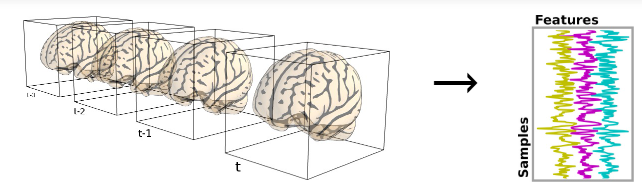

- The design of these NitfitMasker is similar to scikit-learn. First, objects are initialized with some parameters guiding the transformation (unrelated to the data). Then the fit() method should be called possibly specifying some data-related information (such as number of images process) to perform some initial computation (fittig a mask based on the data). Finally, transform() can be called, with the data as argument, to perform some computation on data themselves (extracting time series from images).

### Normalization using NitifitMapsMasker
- NitifiMapsMasker performs temporal signal standardization (z-score) by default for each extracted time series, making mean signal zero and standard deviation one, and alllows for confound regression/noise reduction (e.g. movement, physiological noise) and optional smoothing, but its primary focueses on extracting ROI signals and handling cofounds rather than intensity normalization of the underlying image.
- We use a Nilearn class called NifitMapsMasker that gets brain signal time series from the ROIs defined by the atlas. It's important to specify a confounds file here to regress out noise. this confounds file, data.confounds, was generated by fMRIPrep.

In [11]:
# Standarize=True means signals in time series are shifted to zero mean
# and scaled to unit variance
masker = NiftiMapsMasker(maps_img=atlas_filename, standardize=True, memory='nilearn_cache')


time_series = [0] * len(data.func)
labels = [0] * len(data.func)

print(f'time series Length: {len(time_series)}; {time_series}')
print(f'Labels Length: {len(labels)} ; {labels}')

time series Length: 155; [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Labels Length: 155 ; [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [12]:
data.phenotypic

,participant_id,Age,AgeGroup,Child_Adult,Gender,Handedness
154,sub-pixar155,26.00,Adult,adult,M,R
122,sub-pixar123,27.06,Adult,adult,F,R
123,sub-pixar124,33.44,Adult,adult,M,R
124,sub-pixar125,31.00,Adult,adult,M,R
125,sub-pixar126,19.00,Adult,adult,F,R
...,...,...,...,...,...,...
53,sub-pixar054,5.99,5yo,child,M,R
54,sub-pixar055,5.82,5yo,child,M,L
55,sub-pixar056,5.26,5yo,child,F,R
48,sub-pixar049,5.23,5yo,child,M,R


In [13]:
for i in range(0, len(data.func)):
    # Each subject is assigned a number.
    # We get this number here and use it as an index to avoid file ordering problems later.
    sub_num = int(data.phenotypic.iloc[i]['participant_id'][9:]) - 1

    ts = masker.fit_transform(data.func[i], confounds=data.confounds[i])
    time_series[sub_num] = ts
    labels[sub_num] = data.phenotypic.iloc[i]['Child_Adult'] # Whether or not the subject is a child or adult

# Save time series
for i in range(len(time_series)):
  np.savetxt(f'{time_series_dir}/time_series_{i:04d}.csv', time_series[i], delimiter=',')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_set_output.py:319: UserWarning: memory_level is currently set to 0 but a Memory object has been provided. Setting memory_level to 1.
  data_to_wrap = f(self, X, *args, **kwargs)


In [14]:
time_series[0].shape

(168, 39)

In [15]:
labels[0]

'child'

In [36]:
labels.count('child'), labels.count('adult')

(122, 33)

- Calculating partial correlation matric for each time series and taking the mean. This will serve as the basis for edges in graphs we create later.

### conenctivity measure
- measures quantifies functional interactions between brain regions (ROIs) from fMRI data, using the nilearn generates connectomes (brain network maps) by calculating correlation, partial correlation, or tangent space embeddings between extracted time series, revealing patterns of brain synchrony or influence.
- These measures transform time-domain BOLD signals into a matrix representating how regions communicate, with common options like 'correlation (temporary syncrhony)' or 'tangent (direct influence)'
- `correlation`: The most common method, calculating the Pearson correlation (temporal synchrony) between the average time series of different brain regions.
- `Partial_correlation`: measures the direct correlation between regions, removing indirect influences through other regions (often represented as an inverse covariance matrix).
- `tangent`: Embeds correlation matrices into a tangent space, allowing for robust group comparsions often outperforming standard correlation, especially with noisy data.
- `covariance`: Computes the covariance matrix, reflecting direct and indrect relationships

#### Type sof connectomes
1. Structural connectivity (anatomy): Maps the physical, white matter tracts (axons) that physically connect brain regions, revealing the static 'hardware'
2. Functional connectivity (Activity): Maps patterns of correlated activity betweeen regions (e.g. using fMRI), showing which areas work together dynamiclly, revealing the 'software' in action.
#### Pearson Correlation coefficient r
- Indicating the strength and direction of a linear relationship between 2 continous variables, resulting in value from -1 (perfect negative) and +1 (perfect positive), with 0 indicating no linear correlation.
- It works by assessing how closely data points cluster around a straight line, but requires assumptions like normal distribution and linearity.
- 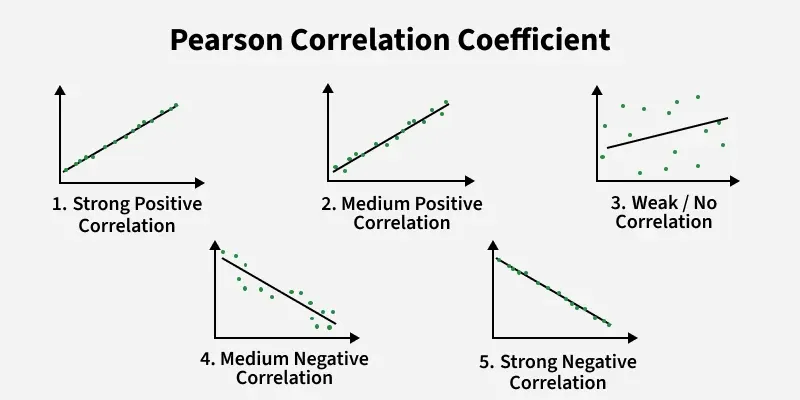

- Assumptions of PCC
  1. Lienar relationship: Linear relation between 2 variables
  2. Normality: The variables should follow a normal distribution
  3. Homoscedasticity: One varible should remaing consistent across all values of the other variables. The spread of data should be uniform.
  4. Interval or raito Scale: E
  5. Independent
- Formula: Calculates the covariance of the variables and normalizes it by their standard deviations. It provides scale-independent measure means it is unaffected by the unit of measurement.
- 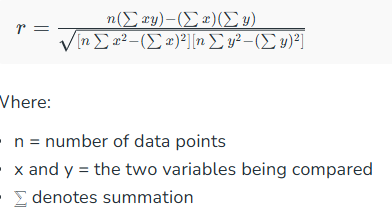


In [16]:
corr_measure = ConnectivityMeasure(kind='correlation')
pcorr_measure = ConnectivityMeasure(kind='partial correlation')
tan_measure = ConnectivityMeasure(kind='tangent')

corr_matrices = corr_measure.fit_transform(time_series)
pcorr_matrices = pcorr_measure.fit_transform(time_series)
tan_matrices = tan_measure.fit_transform(time_series)

In [17]:
corr_matrices.shape, pcorr_matrices.shape, tan_matrices.shape

((155, 39, 39), (155, 39, 39), (155, 39, 39))

In [18]:
pcorr_matrices[0]

array([[ 1.        ,  0.39741024,  0.03129417, ...,  0.060237  ,
         0.29314746, -0.08966591],
       [ 0.39741024,  1.        , -0.03481681, ..., -0.0918979 ,
        -0.22582868,  0.08442552],
       [ 0.03129417, -0.03481681,  1.        , ..., -0.11370762,
        -0.08773217, -0.27968141],
       ...,
       [ 0.060237  , -0.0918979 , -0.11370762, ...,  1.        ,
        -0.01023388,  0.00354129],
       [ 0.29314746, -0.22582868, -0.08773217, ..., -0.01023388,
         1.        ,  0.38746366],
       [-0.08966591,  0.08442552, -0.27968141, ...,  0.00354129,
         0.38746366,  1.        ]])

In [19]:
# Get average partical correlation matrix across time series and save
avg_pcorr_matrix = np.mean(pcorr_matrices, axis=0)
np.savetxt(avg_pcorr_file, avg_pcorr_matrix, delimiter=',')

# Save correlation and partial correlation matrices
for i in range(0, len(corr_matrices)):
    np.savetxt(f'{corr_matrices_dir}/corr_{i:04d}.csv', corr_matrices[i], delimiter=',')
    np.savetxt(f'{pcorr_matrices_dir}/pcorr_{i:04d}.csv', pcorr_matrices[i], delimiter=',')
    np.savetxt(f'{tan_matrices_dir}/tan_{i:04d}.csv', tan_matrices[i], delimiter=',')

# Save labels
label_nums = [0 if label == 'child' else 1 for label in labels]
np.savetxt(labels_file, np.asarray(label_nums).astype(int), delimiter=',')

- Visualize the functional connectome!

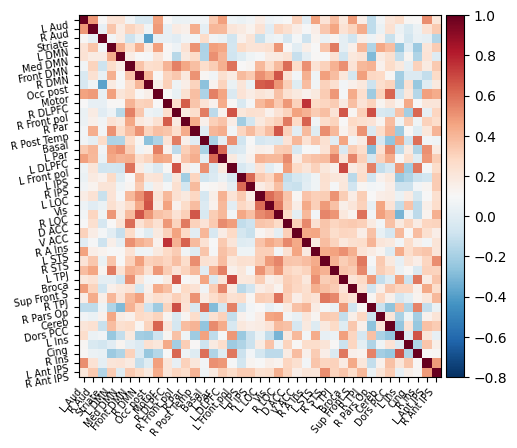

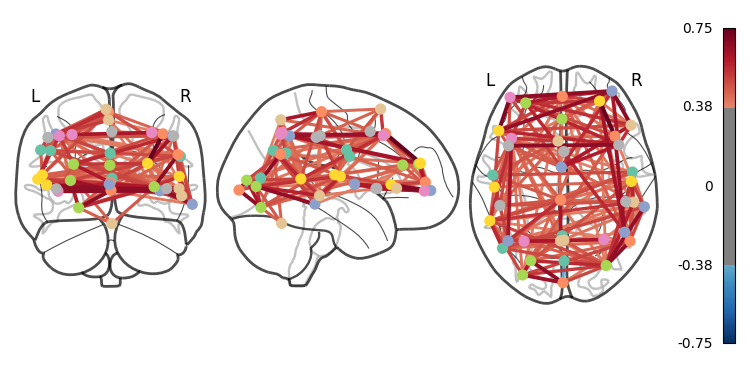

In [20]:
# Partial correlation matrix
plotting.plot_matrix(corr_matrices[0], labels=atlas_labels, colorbar=True, vmax=1, vmin=-0.8)

# Connectome over brain schematic
coords = atlas.region_coords # Get center corrdinates of each ROI
plotting.plot_connectome(corr_matrices[0], coords, edge_threshold="80%", colorbar=True)

- Define a custome class for our dataset
- To build the graphs, we load up the partial correlation matrices we calculated earlier. Edges are formed between ROIs and their non-zero correlates
- Then we grab our correlation matrices and use them as features for our graph.

# HELPER FUNCTIONS - FEATURE EXTRACTION

In [79]:
def extract_rich_node_features(ts):
    """
    Extract comprehensive features from time series

    Args:
        ts: numpy array of shape (timepoints, n_rois)

    Returns:
        numpy array of shape (n_rois, 14 features)
    """
    features = []

    # Basic statistics (5 features)
    features.append(np.mean(ts, axis=0))
    features.append(np.std(ts, axis=0))
    features.append(np.median(ts, axis=0))
    features.append(np.percentile(ts, 25, axis=0))
    features.append(np.percentile(ts, 75, axis=0))

    # Range statistics (3 features)
    features.append(np.max(ts, axis=0))
    features.append(np.min(ts, axis=0))
    features.append(np.ptp(ts, axis=0))

    # Higher order moments (2 features)
    features.append(stats.skew(ts, axis=0))
    features.append(stats.kurtosis(ts, axis=0))

    # Frequency domain (2 features)
    fft_features = np.abs(np.fft.fft(ts, axis=0))
    low_freq = np.mean(fft_features[:len(fft_features)//4], axis=0)
    mid_freq = np.mean(fft_features[len(fft_features)//4:len(fft_features)//2], axis=0)
    features.append(low_freq)
    features.append(mid_freq)

    # Autocorrelation (1 feature)
    autocorr = []
    for i in range(ts.shape[1]):
        if len(ts[:, i]) > 1:
            try:
                corr_val = np.corrcoef(ts[:-1, i], ts[1:, i])[0, 1]
                autocorr.append(corr_val if not np.isnan(corr_val) else 0)
            except:
                autocorr.append(0)
        else:
            autocorr.append(0)
    features.append(np.array(autocorr))

    # Coefficient of variation (1 feature)
    cv = np.std(ts, axis=0) / (np.mean(ts, axis=0) + 1e-8)
    features.append(cv)

    return np.column_stack(features)

In [80]:
def adaptive_threshold(corr_matrix, percentile=85, min_edges=50):
    """
    Compute adaptive threshold for edge creation
    """
    n = corr_matrix.shape[0]
    upper_tri_indices = np.triu_indices(n, k=1)
    upper_tri = corr_matrix[upper_tri_indices]
    abs_upper = np.abs(upper_tri)

    threshold = np.percentile(abs_upper, percentile)

    n_edges_above = np.sum(abs_upper > threshold) * 2
    if n_edges_above < min_edges:
        sorted_vals = np.sort(abs_upper)[::-1]
        if len(sorted_vals) > min_edges // 2:
            threshold = sorted_vals[min_edges // 2]
        else:
            threshold = np.min(abs_upper)

    return threshold

print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


# DATASET CLASS

### InMemoryDataset
- It is a base class in PyG for creating graph datasets that fit entirely into CPU memory.
- It simplifies dataset creation by automatically handling the downloading and processing of data, caching the results for future use.
- torch_geometric.data.InMemoryDataset inherits from torch_geometric.data.Dataset and should be used if the whole dataset fits into CPU memory.


In [21]:
class MultiConnectivityDataset(InMemoryDataset):
  '''
  Dataset with multiple connectivity measures as edge features
  '''
  def __init__(self, root, time_series, labels, threshold=0.3,
               transform=None, pre_transform=None):
    self.time_series = time_series
    self.labels = labels
    self.threshold = threshold
    self.n_rois = time_series[0].shape[1]
    self.n_participants = len(time_series)

    super().__init__(root, transform, pre_transform)
    self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

  @property
  def raw_file_names(self):
    return []

  @property
  def processed_file_names(self):
    return ['multi_connectivity_graphs.pt']

  def download(self):
    pass

  def process(self):
    '''
    Converts raw data into GNN-readable format by constructing
    graphs out of connectivity matrices.
    '''

    corr_measure = ConnectivityMeasure(kind='correlation')
    pcorr_measure = ConnectivityMeasure(kind='partial correlation')
    tan_measure = ConnectivityMeasure(kind='tangent')

    print('Computing correlation....')
    corr_matrices = corr_measure.fit_transform(self.time_series)
    print('Computing partial correlation....')
    pcorr_matrices = pcorr_measure.fit_transform(self.time_series)
    print('Computing tangent....')
    tan_matrices = tan_measure.fit_transform(self.time_series)

    graphs = []

    for idx in range(self.n_participants):
      ts = self.time_series[idx]

      # Node features
      x = torch.tensor(np.column_stack([
          np.mean(ts, axis=0),
          np.std(ts, axis=0),
      ]), dtype=torch.float)

      # Build edges using correlation, but iclude both measures as features
      edge_index = []
      edge_attr = []

      for i in range(self.n_rois):
        for j in range(i+1, self.n_rois):
          if abs(corr_matrices[idx][i, j]) > self.threshold:
            edge_index.extend([[i, j], [j, i]])

            # Multiple edge features
            feat = [
                corr_matrices[idx][i, j],
                pcorr_matrices[idx][i, j],
                abs(corr_matrices[idx][i, j]),
                1.0 if corr_matrices[idx][i, j] > 0 else -1.0,  # Sign
            ]
            edge_attr.extend([feat, feat])

      edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
      edge_attr = torch.tensor(edge_attr, dtype=torch.float)

      y = torch.tensor([1 if self.labels[idx] == 'adult' else 0], dtype=torch.long)

      # Graph-level tangent feature
      # graph_feet = torch.tensor(tan_matrices[idx].flatten(), dtype=torch.float)

      data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, num_nodes=self.n_rois)
      # data.graph_feet = graph_feet
      graphs.append(data)

    print(f"Created {len(graphs)} graphs")

    data, slices = self.collate(graphs)
    torch.save((data, slices), self.processed_paths[0])
    print(f"Saved to {self.processed_paths[0]}")

  def get_labels(self):
    return torch.cat([self[i].y for i in range(len(self))], dim=0)

  def get_statistics(self):
    print(f"\n{'='*60}")
    print("Dataset Statistics")
    print(f"{'='*60}")
    print(f"Number of graphs: {len(self)}")
    print(f"Number of nodes per graph: {self.n_rois}")
    print(f"Number of node features: {self[0].x.shape[1]}")
    print(f"Number of edge features: {self[0].edge_attr.shape[1] if self[0].edge_attr.numel() > 0 else 0}")

    # Edge statistics
    num_edges = [data.edge_index.shape[1] for data in self]
    print(f"Average edges: {np.mean(num_edges):.2f} ± {np.std(num_edges):.2f}")
    print(f"Min edges: {np.min(num_edges)}, Max edges: {np.max(num_edges)}")

    # Label distribution
    labels = self.get_labels().numpy()
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\nLabel distribution:")
    for label, count in zip(unique, counts):
      label_name = 'Child' if label == 0 else 'Adult'
      print(f"  {label_name}: {count} ({count/len(labels)*100:.1f}%)")
    print(f"{'='*60}\n")

dataset = MultiConnectivityDataset('Multidataset_pyg', time_series=time_series, labels=labels)

Computing correlation....
Computing partial correlation....
Computing tangent....
Created 155 graphs
Saved to Multidataset_pyg/processed/multi_connectivity_graphs.pt


In [81]:
class BrainDataset(InMemoryDataset):
    """
    dataset with all fixes applied:
    - Rich node features (14 features)
    - Adaptive edge thresholding
    - Feature normalization
    - Better edge features
    """

    def __init__(self, root, time_series, labels, threshold_percentile=85,
                 normalize_features=True, transform=None, pre_transform=None):
        self.time_series = time_series
        self.labels = labels
        self.threshold_percentile = threshold_percentile
        self.normalize_features = normalize_features
        self.n_rois = time_series[0].shape[1]
        self.n_participants = len(time_series)

        super().__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def raw_file_names(self):
        return []

    @property
    def processed_file_names(self):
        return ['brain_graphs.pt']

    def download(self):
        pass

    def process(self):
        print('\nProcessing dataset...')
        print('Computing connectivity matrices...')

        corr_measure = ConnectivityMeasure(kind='correlation')
        pcorr_measure = ConnectivityMeasure(kind='partial correlation')

        corr_matrices = corr_measure.fit_transform(self.time_series)
        pcorr_matrices = pcorr_measure.fit_transform(self.time_series)

        print('Extracting features...')
        all_node_features = []
        all_edge_features = []
        graph_info = []

        # First pass: extract all features
        for idx in range(self.n_participants):
            ts = self.time_series[idx]

            # Rich node features
            node_feat = extract_rich_node_features(ts)
            all_node_features.append(node_feat)

            # Adaptive threshold
            threshold = adaptive_threshold(
                corr_matrices[idx],
                percentile=self.threshold_percentile
            )

            # Build edges
            edge_index = []
            edge_attr = []

            for i in range(self.n_rois):
                for j in range(i+1, self.n_rois):
                    if abs(corr_matrices[idx][i, j]) > threshold:
                        edge_index.extend([[i, j], [j, i]])

                        feat = [
                            corr_matrices[idx][i, j],
                            pcorr_matrices[idx][i, j],
                            abs(corr_matrices[idx][i, j]),
                            1.0 if corr_matrices[idx][i, j] > 0 else -1.0,
                        ]
                        edge_attr.extend([feat, feat])

            all_edge_features.append(np.array(edge_attr) if edge_attr else np.array([]))
            graph_info.append({
                'edge_index': edge_index,
                'n_edges': len(edge_index)
            })

        # Normalize features
        if self.normalize_features:
            print('Normalizing features...')
            all_nodes_stacked = np.vstack(all_node_features)
            node_scaler = StandardScaler()
            node_scaler.fit(all_nodes_stacked)

            edge_features_list = [ef for ef in all_edge_features if len(ef) > 0]
            if edge_features_list:
                all_edges_stacked = np.vstack(edge_features_list)
                edge_scaler = StandardScaler()
                edge_scaler.fit(all_edges_stacked)
            else:
                edge_scaler = None

        # Create graphs
        print('Creating graph objects...')
        graphs = []

        for idx in range(self.n_participants):
            # Node features
            node_feat = all_node_features[idx]
            if self.normalize_features:
                node_feat = node_scaler.transform(node_feat)
            x = torch.tensor(node_feat, dtype=torch.float)

            # Edge features
            if graph_info[idx]['n_edges'] > 0:
                edge_index = torch.tensor(
                    graph_info[idx]['edge_index'],
                    dtype=torch.long
                ).t().contiguous()

                edge_attr = all_edge_features[idx]
                if self.normalize_features and edge_scaler is not None:
                    edge_attr = edge_scaler.transform(edge_attr)
                edge_attr = torch.tensor(edge_attr, dtype=torch.float)
            else:
                edge_index = torch.tensor(
                    [[i, i] for i in range(self.n_rois)],
                    dtype=torch.long
                ).t().contiguous()
                edge_attr = torch.zeros((self.n_rois, 4), dtype=torch.float)

            # Label
            y = torch.tensor(
                [1 if self.labels[idx] == 'adult' else 0],
                dtype=torch.long
            )

            data = Data(
                x=x,
                edge_index=edge_index,
                edge_attr=edge_attr,
                y=y,
                num_nodes=self.n_rois
            )
            graphs.append(data)

        print(f'Created {len(graphs)} graphs')

        data, slices = self.collate(graphs)
        torch.save((data, slices), self.processed_paths[0])
        print(f'Saved to {self.processed_paths[0]}')

    def get_labels(self):
        return torch.cat([self[i].y for i in range(len(self))], dim=0)

    def get_statistics(self):
        print(f"\n{'='*60}")
        print("Dataset Statistics")
        print(f"{'='*60}")
        print(f"Number of graphs: {len(self)}")
        print(f"Number of nodes per graph: {self.n_rois}")
        print(f"Number of node features: {self[0].x.shape[1]}")
        print(f"Number of edge features: {self[0].edge_attr.shape[1]}")

        num_edges = [data.edge_index.shape[1] for data in self]
        print(f"Average edges: {np.mean(num_edges):.2f} ± {np.std(num_edges):.2f}")
        print(f"Min edges: {np.min(num_edges)}, Max edges: {np.max(num_edges)}")

        labels = self.get_labels().numpy()
        unique, counts = np.unique(labels, return_counts=True)
        print(f"\nLabel distribution:")
        for label, count in zip(unique, counts):
            label_name = 'Child' if label == 0 else 'Adult'
            print(f"  {label_name}: {count} ({count/len(labels)*100:.1f}%)")
        print(f"{'='*60}\n")

print("✓ Dataset class defined")


✓ Dataset class defined


In [82]:
print("\n" + "="*80)
print("CREATING DATASET")
print("="*80)

dataset = BrainDataset(
    root='brain_dataset_pyg',
    time_series=time_series,
    labels=labels,
    threshold_percentile=85,
    normalize_features=True
)


CREATING DATASET

Processing dataset...
Computing connectivity matrices...
Extracting features...
Normalizing features...
Creating graph objects...
Created 155 graphs
Saved to brain_dataset_pyg/processed/brain_graphs.pt


In [108]:
for i in range(5):
  print(dataset[i])

Data(x=[39, 14], edge_index=[2, 222], edge_attr=[222, 4], y=[1], num_nodes=39)
Data(x=[39, 14], edge_index=[2, 222], edge_attr=[222, 4], y=[1], num_nodes=39)
Data(x=[39, 14], edge_index=[2, 222], edge_attr=[222, 4], y=[1], num_nodes=39)
Data(x=[39, 14], edge_index=[2, 222], edge_attr=[222, 4], y=[1], num_nodes=39)
Data(x=[39, 14], edge_index=[2, 222], edge_attr=[222, 4], y=[1], num_nodes=39)


In [83]:
print(dataset)

BrainDataset(155)


In [84]:
dataset.get_labels()

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [85]:
dataset.get_statistics()


Dataset Statistics
Number of graphs: 155
Number of nodes per graph: 39
Number of node features: 14
Number of edge features: 4
Average edges: 222.00 ± 0.00
Min edges: 222, Max edges: 222

Label distribution:
  Child: 122 (78.7%)
  Adult: 33 (21.3%)



In [25]:
for i in range(5):
  print(dataset[i])

Data(x=[39, 2], edge_index=[2, 486], edge_attr=[486, 3], y=[1], num_nodes=39)
Data(x=[39, 2], edge_index=[2, 346], edge_attr=[346, 3], y=[1], num_nodes=39)
Data(x=[39, 2], edge_index=[2, 314], edge_attr=[314, 3], y=[1], num_nodes=39)
Data(x=[39, 2], edge_index=[2, 616], edge_attr=[616, 3], y=[1], num_nodes=39)
Data(x=[39, 2], edge_index=[2, 314], edge_attr=[314, 3], y=[1], num_nodes=39)


# GNN Architectures for Brain Graph Classification

**Architecture 1: Graph Convolutional Network (GCN)**

In [86]:
class GCN_Classifier(nn.Module):
  """
    Graph Covolution network with
      - Multi-scale pooling (mean + max + sum)
      - Residual connections
      - Deeper classification head
  """
  def __init__(self, num_node_features, num_classes=2, hidden_channels=128,
               num_layers=4, dropout=0.3, use_residual=True):
    super().__init__()

    self.num_layers = num_layers
    self.dropout = dropout
    self.use_residual = use_residual

    # GNN layers
    self.conv1 = GCNConv(num_node_features, hidden_channels)
    self.bn1 = BatchNorm(hidden_channels)

    # Hidden layers
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    for i in range(num_layers - 2):
      self.convs.append(GCNConv(hidden_channels, hidden_channels))
      self.bns.append(BatchNorm(hidden_channels))

    self.conv_out = GCNConv(hidden_channels, hidden_channels)
    self.bn_out = BatchNorm(hidden_channels)

    # Multi-scale pooling
    pooled_dim = hidden_channels * 3

    # Classification head
    self.fc1 = Linear(pooled_dim, hidden_channels)
    self.fc2 = Linear(hidden_channels, hidden_channels//2)
    self.fc3 = Linear(hidden_channels//2, num_classes)

  def forward(self, data):
    x, edge_index, batch = data.x, data.edge_index, data.batch

    # First layer
    x = self.conv1(x, edge_index)
    x = self.bn1(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)

    # Hidden layers
    for conv, bn in zip(self.convs, self.bns):
      identity = x
      x = conv(x, edge_index)
      x = bn(x)
      if self.use_residual:
        x = x + identity
      x = F.relu(x)
      x = F.dropout(x, p=self.dropout, training=self.training)

    # Output layer
    x = self.conv_out(x, edge_index)
    x = self.bn_out(x)
    x = F.relu(x)

    # Multi-scale pooling
    x_mean = global_mean_pool(x, batch)
    x_max = global_max_pool(x, batch)
    x_sum = global_add_pool(x, batch)
    x = torch.cat([x_mean, x_max, x_sum], dim=1)

    # Classification
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc1(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc2(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc3(x)

    return x

In [87]:
GCN_Classifier(dataset.num_node_features)

GCN_Classifier(
  (conv1): GCNConv(14, 128)
  (bn1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convs): ModuleList(
    (0-1): 2 x GCNConv(128, 128)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_out): GCNConv(128, 128)
  (bn_out): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

**Architecture 2: Graph Attention Network (GAT)**

In [88]:
class GAT_Classifier(nn.Module):
  """
    Graph Attention Network with improvements
      - Multi-head attention
      - Edge attention
      - Multi-scale pooling
  """
  def __init__(self, num_node_features, num_classes=2, hidden_channels=128,
               num_layers=4, heads=4, dropout=0.3):
    super().__init__()

    self.num_layers = num_layers
    self.dropout = dropout

    # Input layer with multi-head attention
    self.conv1 = GATConv(num_node_features, hidden_channels, heads=heads, dropout=dropout)
    self.bn1 = BatchNorm(hidden_channels * heads)

    # Hidden layers
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    for _ in range(num_layers - 2):
      self.convs.append(GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout))
      self.bns.append(BatchNorm(hidden_channels * heads))

    # Output layer (single head)
    self.conv_out = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout)
    self.bn_out = BatchNorm(hidden_channels)

    # Multi-scale pooling
    pooled_dim = hidden_channels * 3

    # Classification
    self.fc1 = Linear(pooled_dim, hidden_channels)
    self.fc2 = Linear(hidden_channels, hidden_channels // 2)
    self.fc3 = Linear(hidden_channels // 2, num_classes)

  def forward(self, data):
    x, edge_index, batch = data.x, data.edge_index, data.batch

    # First layer
    x = self.conv1(x, edge_index)
    x = self.bn1(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)

    # Hidden layers
    for conv, bn in zip(self.convs, self.bns):
      x = conv(x, edge_index)
      x = bn(x)
      x = F.elu(x)
      x = F.dropout(x, p=self.dropout, training=self.training)

    # Output layer
    x = self.conv_out(x, edge_index)
    x = self.bn_out(x)
    x = F.elu(x)

    # Global pooling
    x_mean = global_mean_pool(x, batch)
    x_max = global_max_pool(x, batch)
    x_sum = global_add_pool(x, batch)
    x = torch.cat([x_mean, x_max, x_sum], dim=1)

    # classification
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc1(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc2(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc3(x)

    return x


In [89]:
GAT_Classifier(dataset.num_features)

GAT_Classifier(
  (conv1): GATConv(14, 128, heads=4)
  (bn1): BatchNorm(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convs): ModuleList(
    (0-1): 2 x GATConv(512, 128, heads=4)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_out): GATConv(512, 128, heads=1)
  (bn_out): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

**Architecture 3: Graph Isomorphism Network (GIN)**

In [90]:
class GIN_Classifier(nn.Module):
  '''
    Graph Isomorphism Network with
      - Expressive MLPs
      - Sum pooling (standard for GIN)
      - Additional pooling strategies
  '''
  def __init__(self, num_node_features, num_classes=2, hidden_channels=128,
               num_layers=4, dropout=0.3):
    super().__init__()

    self.num_layers = num_layers
    self.dropout = dropout

    # GIN layers with MLPs
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()

    # Input layer
    nn1 = nn.Sequential(
        Linear(num_node_features, hidden_channels),
        BatchNorm(hidden_channels),
        nn.ReLU(),
        Linear(hidden_channels, hidden_channels),
        BatchNorm(hidden_channels),
        nn.ReLU()
    )
    self.convs.append(GINConv(nn1, train_eps=True))
    self.bns.append(BatchNorm(hidden_channels))

    # Hidden layers
    for _ in range(num_layers-1):
      nn_hidden = nn.Sequential(
          Linear(hidden_channels, hidden_channels),
          BatchNorm(hidden_channels),
          nn.ReLU(),
          Linear(hidden_channels, hidden_channels),
          BatchNorm(hidden_channels),
          nn.ReLU()
      )
      self.convs.append(GINConv(nn_hidden, train_eps=True))
      self.bns.append(BatchNorm(hidden_channels))

    # Mutli-scale pooling
    pooled_dim = hidden_channels * 3

    # Classification head
    self.fc1 = Linear(pooled_dim, hidden_channels)
    self.fc2 = Linear(hidden_channels, hidden_channels // 2)
    self.fc3 = Linear(hidden_channels // 2, num_classes)

  def forward(self, data):
    x, edge_index, batch = data.x, data.edge_index, data.batch

    # GIN layers
    for conv, bn in zip(self.convs, self.bns):
      x = conv(x, edge_index)
      x = bn(x)
      x = F.relu(x)
      x = F.dropout(x, p=self.dropout, training=self.training)

    # Multi-scale pooling (GIN uses sum, but we add others)
    x_sum = global_add_pool(x, batch) # GIN typically uses sum pooling
    x_mean = global_mean_pool(x, batch)
    x_max = global_max_pool(x, batch)
    x = torch.cat([x_sum, x_mean, x_max], dim=1)

    # Classification
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc1(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc2(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc3(x)

    return x

In [91]:
GIN_Classifier(dataset.num_features)

GIN_Classifier(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=14, out_features=128, bias=True)
      (1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    ))
    (1-3): 3 x GINConv(nn=Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    ))
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc

**Architcture 4: GraphSAGE**

In [92]:
class GraphSAGE_Classifier(nn.Module):
  '''
    GraphSAGE with
      - Neighborhood aggregation
      - Multi-scale pooling
      - Deeper architecture
  '''
  def __init__(self, num_node_features, num_classes=2, hidden_channels=128,
               num_layers=4, dropout=0.3, aggr='mean'):
    super().__init__()

    self.num_layers = num_layers
    self.dropout = dropout

    # SAGE layers
    self.conv1 = SAGEConv(num_node_features, hidden_channels, aggr=aggr)
    self.bn1 = BatchNorm(hidden_channels)

    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    for _ in range(num_layers-2):
      self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr=aggr))
      self.bns.append(BatchNorm(hidden_channels))

    # Output layer
    self.conv_out = SAGEConv(hidden_channels, hidden_channels, aggr=aggr)
    self.bn_out = BatchNorm(hidden_channels)

    # Multi-scale pooling
    pooled_dim = hidden_channels * 3

    # Classification head
    self.fc1 = Linear(pooled_dim, hidden_channels)
    self.fc2 = Linear(hidden_channels, hidden_channels // 2)
    self.fc3 = Linear(hidden_channels // 2, num_classes)

  def forward(self, data):
    x, edge_index, batch = data.x, data.edge_index, data.batch

    # First layer
    x = self.conv1(x, edge_index)
    x = self.bn1(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)

    # Hidden layers
    for conv, bn in zip(self.convs, self.bns):
      x = conv(x, edge_index)
      x = bn(x)
      x = F.relu(x)
      x = F.dropout(x, p=self.dropout, training=self.training)

    # Outpout layer
    x = self.conv_out(x, edge_index)
    x = self.bn_out(x)
    x = F.relu(x)

    # Multi-scale pooling
    x_mean = global_mean_pool(x, batch)
    x_max = global_max_pool(x, batch)
    x_sum = global_add_pool(x, batch)
    x = torch.cat([x_mean, x_max, x_sum], dim=1)

    # Classification
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc1(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc2(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc3(x)

    return x

In [93]:
GraphSAGE_Classifier(dataset.num_features)

GraphSAGE_Classifier(
  (conv1): SAGEConv(14, 128, aggr=mean)
  (bn1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (convs): ModuleList(
    (0-1): 2 x SAGEConv(128, 128, aggr=mean)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv_out): SAGEConv(128, 128, aggr=mean)
  (bn_out): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

**Architecture 5: Hierarchical Graph Neural Network  with Multiple Pooling**

In [94]:
class HGNN_Classifier(nn.Module):
  '''
  Hybrid architecture combining different GNN types:
    - Initial GCN layer for basic graph structure
    - GAT layer for attention-based aggregation
    - GIN layer for expressive power
    - Multi-scale pooling
  '''
  def __init__(self, num_node_features, num_classes=2, hidden_channels=128,
               dropout=0.3, heads=4):
    super().__init__()

    self.dropout = dropout

    # Layer 1: GNN for basic structure
    self.conv1 = GCNConv(num_node_features, hidden_channels)
    self.bn1 = BatchNorm(hidden_channels)

    # Layer 2: GAT for attenton
    self.conv2 = GATConv(hidden_channels, hidden_channels, heads=heads, dropout=dropout)
    self.bn2 = BatchNorm(hidden_channels * heads)

    # Layer 3: GIN for expressive power
    ginn_nn = nn.Sequential(
        Linear(hidden_channels * heads, hidden_channels),
        BatchNorm(hidden_channels),
        nn.ReLU(),
        Linear(hidden_channels, hidden_channels),
    )
    self.conv3 = GINConv(ginn_nn, train_eps=True)
    self.bn3 = BatchNorm(hidden_channels)

    # Layer 4: GraphSAGE for neighborhood aggregation
    self.conv4 = SAGEConv(hidden_channels, hidden_channels)
    self.bn4 = BatchNorm(hidden_channels)

    # Multiple pooling strategies
    pooled_dim = hidden_channels * 3 # mean + max + sum

    # Classification head
    self.fc1 = Linear(pooled_dim, hidden_channels)
    self.fc2 = Linear(hidden_channels, hidden_channels // 2)
    self.fc3 = Linear(hidden_channels // 2, num_classes)

  def forward(self, data):
    x, edge_index, batch = data.x, data.edge_index, data.batch

    # Layer 1: GCN
    x = self.conv1(x, edge_index)
    x = self.bn1(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)

    # Layer 2: GAT
    x = self.conv2(x, edge_index)
    x = self.bn2(x)
    x = F.relu(x)
    x = F.elu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)

    # Layer 3: GIN
    x = self.conv3(x, edge_index)
    x = self.bn3(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)

    # Layer 4: GraphSAGE
    x = self.conv4(x, edge_index)
    x = self.bn4(x)
    x = F.relu(x)

    # Multiple pooling strategies
    x_mean = global_mean_pool(x, batch)
    x_max = global_max_pool(x, batch)
    x_sum = global_add_pool(x, batch)
    # Concatenate pooled representations
    x = torch.cat([x_mean, x_max, x_sum], dim=1)

    # Classification
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc1(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc2(x)
    x = F.relu(x)
    x = F.dropout(x, p=self.dropout, training=self.training)
    x = self.fc3(x)

    return x

In [95]:
HGNN_Classifier(dataset.num_features)

HGNN_Classifier(
  (conv1): GCNConv(14, 128)
  (bn1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GATConv(128, 128, heads=4)
  (bn2): BatchNorm(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  ))
  (bn3): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): SAGEConv(128, 128, aggr=mean)
  (bn4): BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)

In [96]:
# Define all architectures
architectures = {
    'GCN': {
        'class': GCN_Classifier,
        'params': {'hidden_channels': 128, 'num_layers': 4, 'dropout': 0.3, 'use_residual': True},
        'description': 'Standard GCN with residual connections'
    },
    'GAT': {
        'class': GAT_Classifier,
        'params': {'hidden_channels': 128, 'num_layers': 4, 'heads': 4, 'dropout': 0.3},
        'description': 'Graph Attention Network with multi-head attention'
    },
    'GIN': {
        'class': GIN_Classifier,
        'params': {'hidden_channels': 128, 'num_layers': 4, 'dropout': 0.3},
        'description': 'Graph Isomorphism Network'
    },
    'GraphSAGE':{
        'class': GraphSAGE_Classifier,
        'params': {'hidden_channels': 128, 'num_layers': 4, 'dropout': 0.3, 'aggr': 'mean'},
        'description': 'GraphSAGE with neighborhood sampling'
    },
    'Hybrid': {
        'class': HGNN_Classifier,
        'params': {'hidden_channels': 128, 'dropout': 0.3, 'heads': 4},
        'description': 'Hybrid combining GCN, GAT, GIN, and SAGE'
    }
}

print("✓ Architecture configurations ready")

✓ Architecture configurations ready


# HELPER FUNCTIONS - FOCAL LOSS

In [97]:
class FocalLoss(nn.Module):
  '''
    Focal Loss for imbalanced datasets
    Focues training on hard-to-classify examples
  '''
  def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
    super().__init__()
    self.alpha = alpha
    self.gamma = gamma
    self.reduction = reduction

  def forward(self, inputs, targets):
    ce_loss = F.cross_entropy(inputs, targets, reduction='none')
    pt = torch.exp(-ce_loss)
    focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss

    if self.reduction == 'mean':
      return focal_loss.mean()
    elif self.reduction == 'sum':
      return focal_loss.sum()
    return focal_loss
print('Focal Loss defined.')

Focal Loss defined.


# HELPER FUNCTIONS - TRAINING UTILITES

In [98]:
def create_balanced_loader(dataset, batch_size=32):
  '''
    Create DataLoader with balanced sampling for class imbalance
  '''
  labels = dataset.get_labels().numpy()
  class_counts = np.bincount(labels)
  weights = 1. / class_counts[labels]

  sampler = WeightedRandomSampler(
      weights = weights.tolist(),
      num_samples = len(weights),
      replacement = True
  )

  return DataLoader(dataset, batch_size=batch_size, sampler=sampler)

In [99]:
def evaluate_model(model, loader, device):
  '''
    Evaluate model and return comprehensive metrics
  '''
  all_preds = []
  all_labels = []
  all_probs = []

  with torch.no_grad():
    for data in loader:
      data = data.to(device)
      out = model(data)
      probs = F.softmax(out, dim=1)
      preds = out.argmax(dim=1)

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(data.y.cpu().numpy())
      all_probs.extend(probs[:, 1].cpu().numpy())

  acc = accuracy_score(all_labels, all_preds)
  precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
  recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
  f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

  try:
    auc = roc_auc_score(all_labels, all_probs)
  except:
    auc = 0.5

  return {
      'accuracy': acc,
      'precision': precision,
      'recall': recall,
      'f1': f1,
      'auc': auc,
      'predictions': all_preds,
      'labels': all_labels,
      'probabilities': all_probs
  }

In [100]:
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001,
                weight_decay=5e-4, device='cuda', patience=20):
  # Enchanced training with focal loss and early stopped
  model = model.to(device)

  optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode='max',factor=0.5, patience=10, min_lr=1e-6)

  criterion = FocalLoss(alpha=0.25, gamma=2.0)

  best_val_f1 = 0
  best_model_state = None
  patience_counter = 0

  train_losses = []
  val_f1s = []

  for epoch in range(epochs):
    # Train
    model.train()
    total_loss = 0

    for data in train_loader:
      data = data.to(device)
      optimizer.zero_grad()
      out = model(data)
      loss = criterion(out, data.y)
      loss.backward()
      optimizer.step()
      total_loss += loss.item() * data.num_graphs

    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Evalute
    val_metrics = evaluate_model(model, val_loader, device)
    val_f1s.append(val_metrics['f1'])

    scheduler.step(val_metrics['f1'])

    # Early stopping
    if val_metrics['f1'] > best_val_f1:
      best_val_f1 = val_metrics['f1']
      best_model_state = model.state_dict().copy()
      patience_counter = 0
    else:
      patience_counter += 1

    if epoch % 10 == 0:
      print(f"Epoch {epoch:03d} | Loss: {avg_train_loss:.4f} | "
          f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc']:.4f}")

    if patience_counter >= patience:
      print(f"Early stopping at epoch {epoch}")
      break

  if best_model_state is not None:
    model.load_state_dict(best_model_state)

  return model, train_losses, val_f1s

print("✓ Training utilities defined")

✓ Training utilities defined


# RUN MULTI-ARCHITECTURE COMPARION

In [101]:
print(f"Testing {len(architectures)} architectures")
print(f"K-Folds: 5")
print(f"Max Epochs: 100 per training")
print(f"Learning rates to test: [0.0001, 0.0005, 0.001]")
print("="*80 + "\n")

# Store all results
all_results = {}
best_models = {}

# Parameters
k_folds = 5
epochs = 100
batch_size = 32

labels_array = dataset.get_labels().numpy()
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Test each architecture
for arch_name, arch_config in architectures.items():
  print(f"\n{'#'*80}")
  print(f"# Testing: {arch_name}")
  print(f"# {arch_config['description']}")
  print(f"{'#'*80}\n")

  fold_results = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels_array)), labels_array)):
    print(f"\n{'='*60}")
    print(f"Fold {fold+1}/{k_folds}")
    print(f"{'='*60}")

    # Create datasets
    train_dataset = dataset[train_idx.tolist()]
    val_dataset = dataset[val_idx.tolist()]

    # Create loaders
    train_loader = create_balanced_loader(train_dataset, batch_size=batch_size)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Learning rate search
    best_val_f1 = 0
    best_model_state = None
    best_lr = None

    for lr in [0.0001, 0.0005, 0.001]:
      print(f"\nTrying LR: {lr}-------")

      # Initialize model
      model = arch_config['class'](
          num_node_features=dataset[0].x.shape[1],
          num_classes=2,
          **arch_config['params']
      )

      # Train
      trained_model, _, val_f1s =  train_model(
          model, train_loader, val_loader,
          epochs=epochs, lr=lr, device=device, patience=20
      )

      # Check if best
      final_f1 = max(val_f1s) if val_f1s else 0
      if final_f1 > best_val_f1:
        best_val_f1 = final_f1
        best_model_state = trained_model.state_dict()
        best_lr = lr

      print(f"\nBest LR for fold {fold+1}: {best_lr} (F1: {best_val_f1:.4f})")

      # Load best model and evaluate
      model.load_state_dict(best_model_state)
      val_metrics = evaluate_model(model, val_loader, device)
      fold_results.append(val_metrics)

      # Save first fold model
      if fold == 0:
        best_models[arch_name] = best_model_state

      print(f"\nFold {fold+1} Final Results:")
      print(f"  Accuracy:  {val_metrics['accuracy']:.4f}")
      print(f"  Precision: {val_metrics['precision']:.4f}")
      print(f"  Recall:    {val_metrics['recall']:.4f}")
      print(f"  F1:        {val_metrics['f1']:.4f}")
      print(f"  AUC:       {val_metrics['auc']:.4f}")

    all_results[arch_name] = fold_results

    # Print architecture summary
    print(f"\n{'-'*60}")
    print(f"{arch_name} Summary (5-Fold CV)")
    print(f"{'-'*60}")
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    for metric in metrics:
      values = [r[metric] for r in fold_results]
      mean = np.mean(values)
      std = np.std(values)
      print(f"{metric.capitalize():12s}: {mean:.4f} ± {std:.4f}")

print("\n" + "="*80)
print("ALL ARCHITECTURES TESTED!")
print("="*80)

Testing 5 architectures
K-Folds: 5
Max Epochs: 100 per training
Learning rates to test: [0.0001, 0.0005, 0.001]


################################################################################
# Testing: GCN
# Standard GCN with residual connections
################################################################################


Fold 1/5

Trying LR: 0.0001-------
Epoch 000 | Loss: 0.1299 | Val F1: 0.2222 | Val AUC: 0.5333
Epoch 010 | Loss: 0.0516 | Val F1: 0.3333 | Val AUC: 0.7000
Epoch 020 | Loss: 0.0393 | Val F1: 0.6316 | Val AUC: 0.8867
Epoch 030 | Loss: 0.0445 | Val F1: 0.4762 | Val AUC: 0.8400
Epoch 040 | Loss: 0.0297 | Val F1: 0.6250 | Val AUC: 0.8867
Epoch 050 | Loss: 0.0400 | Val F1: 0.5882 | Val AUC: 0.7667
Early stopping at epoch 56

Best LR for fold 1: 0.0001 (F1: 0.6667)

Fold 1 Final Results:
  Accuracy:  0.7742
  Precision: 0.4615
  Recall:    1.0000
  F1:        0.6316
  AUC:       0.9067

Trying LR: 0.0005-------
Epoch 000 | Loss: 0.1239 | Val F1: 0.2667 | Val AUC: 0

# COMPARE AND SELECT BEST ARCHITECTURE

In [102]:
print("\n" + "="*80)
print("OVERALL COMPARISON - ALL ARCHITECTURES")
print("="*80 + "\n")

# Create comparison table
comparison_data = []

for arch_name, results in all_results.items():
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    row = {'Architecture': arch_name}

    for metric in metrics:
        values = [r[metric] for r in results]
        row[f'{metric}_mean'] = np.mean(values)
        row[f'{metric}_std'] = np.std(values)

    comparison_data.append(row)

# Create DataFrame and sort by F1
df_results = pd.DataFrame(comparison_data)
df_results = df_results.sort_values('f1_mean', ascending=False)

# Print ranking
print("Ranking by F1 Score:")
print("-" * 80)
for idx, row in df_results.iterrows():
    print(f"{row['Architecture']:15s} | "
          f"Acc: {row['accuracy_mean']:.4f}±{row['accuracy_std']:.4f} | "
          f"F1: {row['f1_mean']:.4f}±{row['f1_std']:.4f} | "
          f"AUC: {row['auc_mean']:.4f}±{row['auc_std']:.4f}")

# Identify best
best_arch = df_results.iloc[0]['Architecture']
best_f1 = df_results.iloc[0]['f1_mean']

print(f"\n{'='*80}")
print(f"🏆 BEST ARCHITECTURE: {best_arch}")
print(f"   Average F1 Score: {best_f1:.4f}")
print(f"   Description: {architectures[best_arch]['description']}")
print(f"{'='*80}\n")



OVERALL COMPARISON - ALL ARCHITECTURES

Ranking by F1 Score:
--------------------------------------------------------------------------------
GCN             | Acc: 0.7656±0.0820 | F1: 0.6367±0.1002 | AUC: 0.8739±0.0825
GAT             | Acc: 0.7484±0.0658 | F1: 0.6136±0.0657 | AUC: 0.8676±0.0640
Hybrid          | Acc: 0.7462±0.0633 | F1: 0.6094±0.0686 | AUC: 0.8904±0.0569
GraphSAGE       | Acc: 0.7097±0.0726 | F1: 0.5746±0.0870 | AUC: 0.8653±0.0734
GIN             | Acc: 0.6903±0.0926 | F1: 0.5306±0.1174 | AUC: 0.8205±0.1055

🏆 BEST ARCHITECTURE: GCN
   Average F1 Score: 0.6367
   Description: Standard GCN with residual connections



# VISUALIZATION

Creating visualizations...


/tmp/ipython-input-4288288458.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_list, patch_artist=True)
/tmp/ipython-input-4288288458.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_list, patch_artist=True)
/tmp/ipython-input-4288288458.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_list, patch_artist=True)
/tmp/ipython-input-4288288458.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be drop

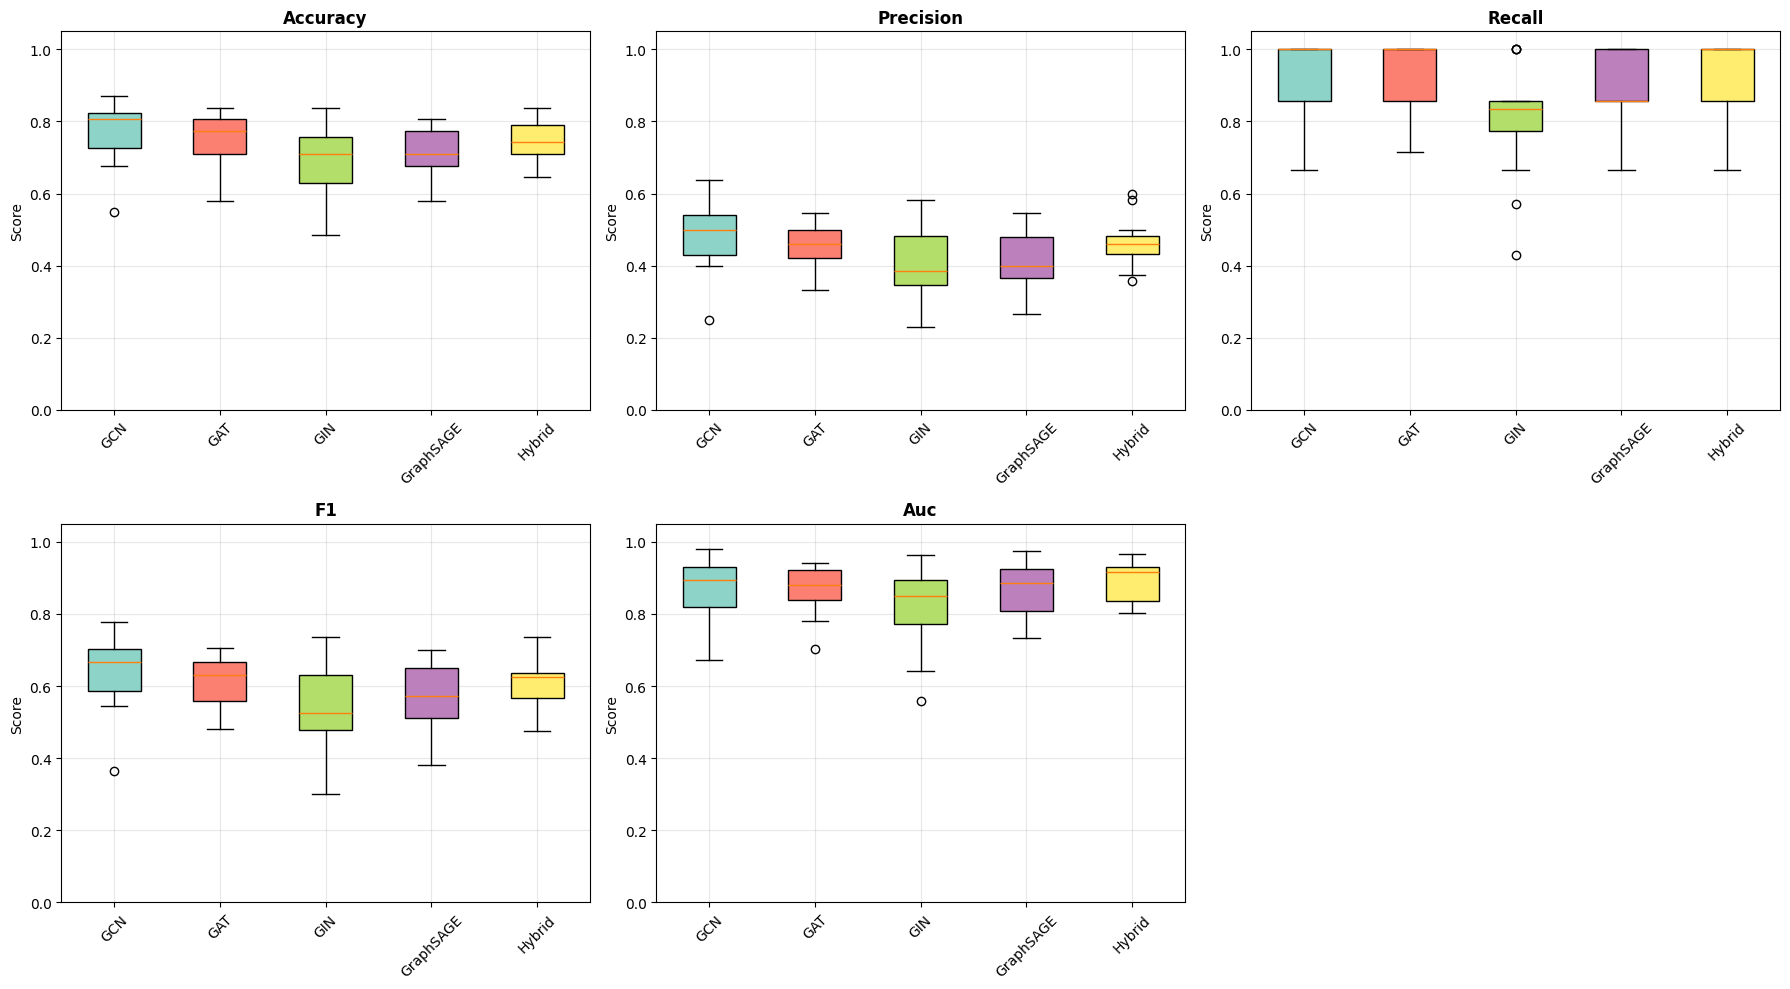

✓ Box plots saved: architecture_comparison.png


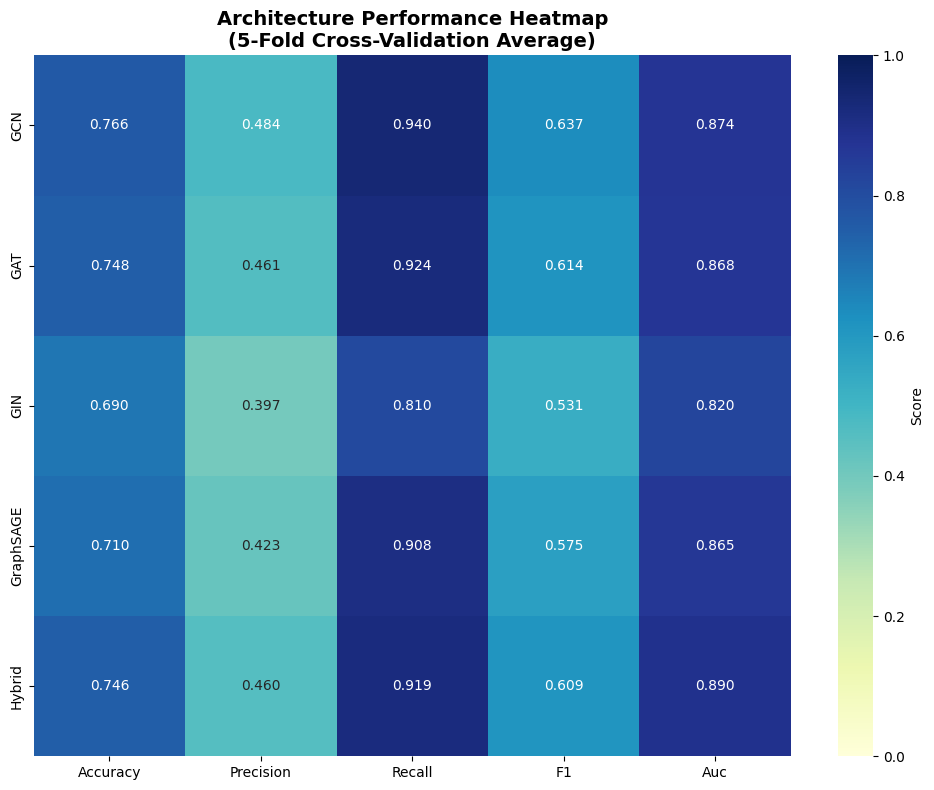

✓ Heatmap saved: performance_heatmap.png


In [103]:
print("Creating visualizations...")

# Box plots for all metrics
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    data = []
    labels_list = []

    for arch_name, results in all_results.items():
        values = [r[metric] for r in results]
        data.append(values)
        labels_list.append(arch_name)

    bp = ax.boxplot(data, labels=labels_list, patch_artist=True)

    colors = plt.cm.Set3(np.linspace(0, 1, len(labels_list)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(f'{metric.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Box plots saved: architecture_comparison.png")

# Performance heatmap
arch_names = list(all_results.keys())
data_matrix = np.zeros((len(arch_names), len(metrics)))

for i, arch_name in enumerate(arch_names):
    for j, metric in enumerate(metrics):
        values = [r[metric] for r in all_results[arch_name]]
        data_matrix[i, j] = np.mean(values)

plt.figure(figsize=(10, 8))
sns.heatmap(data_matrix, annot=True, fmt='.3f',
           xticklabels=[m.capitalize() for m in metrics],
           yticklabels=arch_names,
           cmap='YlGnBu', vmin=0, vmax=1,
           cbar_kws={'label': 'Score'})

plt.title('Architecture Performance Heatmap\n(5-Fold Cross-Validation Average)',
         fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Heatmap saved: performance_heatmap.png")

# LOAD AND USE BEST MODEL

In [104]:
print("\n" + "="*80)
print("LOADING BEST MODEL FOR INFERENCE")
print("="*80)

# Get best model configuration
best_model_class = architectures[best_arch]['class']
best_model_params = architectures[best_arch]['params']

# Create model instance
final_model = best_model_class(
    num_node_features=dataset[0].x.shape[1],
    num_classes=2,
    **best_model_params
)

# Load trained weights
final_model.load_state_dict(best_models[best_arch])
final_model = final_model.to(device)
final_model.eval()

print(f"\n✓ Best model loaded: {best_arch}")
print(f"  Number of parameters: {sum(p.numel() for p in final_model.parameters()):,}")
print(f"  Expected F1 Score: {best_f1:.4f}")
print(f"  Model ready for inference!")

# Example prediction
print("\n" + "="*80)
print("EXAMPLE PREDICTION")
print("="*80)

# Get a sample from the dataset
sample_data = dataset[0].to(device)

with torch.no_grad():
    output = final_model(sample_data.unsqueeze(0) if hasattr(sample_data, 'unsqueeze') else sample_data)
    probs = F.softmax(output, dim=1)
    prediction = output.argmax(dim=1)

print(f"\nSample prediction:")
print(f"  True label: {'Child' if sample_data.y.item() == 0 else 'Adult'}")
print(f"  Predicted: {'Child' if prediction.item() == 0 else 'Adult'}")
print(f"  Confidence: {probs.max().item():.4f}")
print(f"  Probabilities: Child={probs[0, 0].item():.4f}, Adult={probs[0, 1].item():.4f}")



LOADING BEST MODEL FOR INFERENCE

✓ Best model loaded: GCN
  Number of parameters: 110,146
  Expected F1 Score: 0.6367
  Model ready for inference!

EXAMPLE PREDICTION

Sample prediction:
  True label: Child
  Predicted: Child
  Confidence: 0.7795
  Probabilities: Child=0.7795, Adult=0.2205


# SAVE RESULTS AND MODEL

In [105]:
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save best model
torch.save(final_model.state_dict(), 'best_brain_gnn_model.pt')
print("\n✓ Best model saved: best_brain_gnn_model.pt")

# Save results to CSV
df_results.to_csv('architecture_comparison_results.csv', index=False)
print("✓ Results saved: architecture_comparison_results.csv")

# Save detailed results
import json

detailed_results = {}
for arch_name, results in all_results.items():
    detailed_results[arch_name] = {
        'description': architectures[arch_name]['description'],
        'params': str(architectures[arch_name]['params']),
        'fold_results': [
            {k: float(v) if isinstance(v, (int, float, np.number)) else str(v)
             for k, v in result.items() if k in ['accuracy', 'precision', 'recall', 'f1', 'auc']}
            for result in results
        ]
    }

with open('detailed_results.json', 'w') as f:
    json.dump(detailed_results, f, indent=2)

print("✓ Detailed results saved: detailed_results.json")

print("\n" + "="*80)
print("COMPLETE! 🎉")
print("="*80)
print(f"\nBest Architecture: {best_arch}")
print(f"Expected Performance: F1 = {best_f1:.4f}")


SAVING RESULTS

✓ Best model saved: best_brain_gnn_model.pt
✓ Results saved: architecture_comparison_results.csv
✓ Detailed results saved: detailed_results.json

COMPLETE! 🎉

Best Architecture: GCN
Expected Performance: F1 = 0.6367
